# Exploring the datasets
Practice opening and inspecting `climate_grid.nc` and `land_use.tif`.

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
ds = xr.open_dataset('../data/climate_grid.nc')
ds

<xarray.Dataset>
Dimensions:        (time: 3652, lat: 50, lon: 50)
Coordinates:
  * time           (time) datetime64[ns] 2014-01-01 2014-01-02 ... 2023-12-31
  * lat            (lat) float32 36.0 36.2 36.41 36.61 ... 45.39 45.59 45.8 46.0
  * lon            (lon) float32 6.0 6.245 6.49 6.735 ... 17.27 17.51 17.76 18.0
Data variables:
    temperature    (time, lat, lon) float32 ...
    humidity       (time, lat, lon) float32 ...
    wind_speed     (time, lat, lon) float32 ...
    precipitation  (time, lat, lon) float32 ...
    ndvi           (time, lat, lon) float32 ...
Attributes:
    title:        Synthetic climate grid 2014-2023
    institution:  Levantia Fire Risk
    source:       generate_data.py
    history:      Created 2026-05-06T10:27:30.637033
    Conventions:  CF-1.8

In [8]:
ds.dims, ds.data_vars

(Frozen({'time': 3652, 'lat': 50, 'lon': 50}),
 Data variables:
     temperature    (time, lat, lon) float32 ...
     humidity       (time, lat, lon) float32 ...
     wind_speed     (time, lat, lon) float32 ...
     precipitation  (time, lat, lon) float32 ...
     ndvi           (time, lat, lon) float32 ...)

In [11]:
ds.time.values

array(['2014-01-01T00:00:00.000000000', '2014-01-02T00:00:00.000000000',
       '2014-01-03T00:00:00.000000000', ...,
       '2023-12-29T00:00:00.000000000', '2023-12-30T00:00:00.000000000',
       '2023-12-31T00:00:00.000000000'], dtype='datetime64[ns]')

In [19]:
ds['time']

<xarray.DataArray 'time' (time: 3652)>
array(['2014-01-01T00:00:00.000000000', '2014-01-02T00:00:00.000000000',
       '2014-01-03T00:00:00.000000000', ..., '2023-12-29T00:00:00.000000000',
       '2023-12-30T00:00:00.000000000', '2023-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2014-01-01 2014-01-02 ... 2023-12-31

In [ ]:
ds['temperature']

<xarray.DataArray 'temperature' (time: 3652, lat: 50, lon: 50)>
[9130000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 2014-01-01 2014-01-02 ... 2023-12-31
  * lat      (lat) float32 36.0 36.2 36.41 36.61 36.82 ... 45.39 45.59 45.8 46.0
  * lon      (lon) float32 6.0 6.245 6.49 6.735 6.98 ... 17.27 17.51 17.76 18.0
Attributes:
    units:      °C
    long_name:  Near-surface air temperature

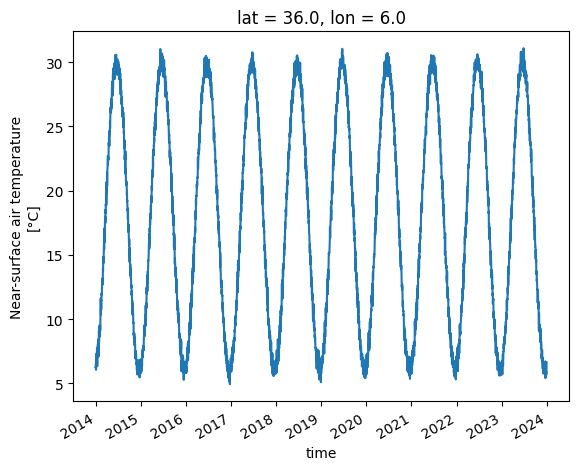

In [37]:
ds['temperature'].sel(lon = 6.0, lat = 36.0).plot()

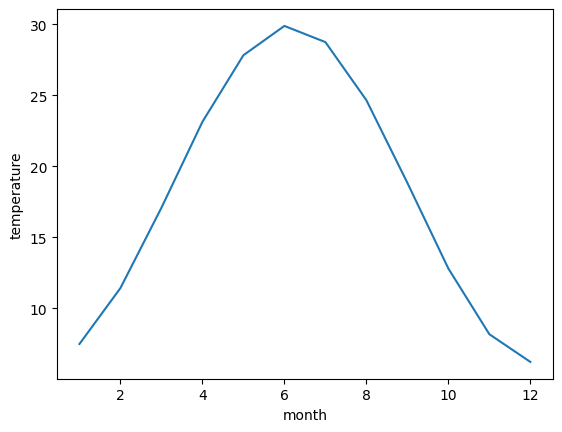

In [45]:
ds['temperature'].mean(('lat', 'lon')).groupby('time.month').mean().plot()

In [ ]:
sns
rasterio.open('../data/land_use.tif').read(1)

array([[4, 4, 4, ..., 4, 4, 4],
       [4, 4, 4, ..., 4, 4, 4],
       [4, 4, 4, ..., 4, 4, 4],
       ...,
       [3, 3, 3, ..., 2, 2, 2],
       [3, 3, 3, ..., 2, 2, 2],
       [3, 3, 3, ..., 2, 2, 2]], dtype=uint8)

In [ ]:
with rasterio.open(DATA / 'land_use.tif') as src:
    land_use = src.read(1)          # read band 1 as numpy array
    transform = src.transform       # pixel → geographic coordinates
    crs = src.crs                   # coordinate reference system
    bounds = src.bounds             # geographic extent
    tags = src.tags()               # metadata tags

print('Shape    :', land_use.shape)
print('CRS      :', crs)
print('Bounds   :', bounds)
print('Transform:', transform)
print('Tags     :', tags)

In [ ]:
# unique classes and their pixel counts
codes, counts = np.unique(land_use, return_counts=True)
labels = {1: 'urban', 2: 'forest', 3: 'shrubland', 4: 'agricultural', 5: 'water'}
for code, count in zip(codes, counts):
    print(f'  {labels[code]:15s} (code {code}): {count} cells  ({count / land_use.size * 100:.1f}%)')

In [ ]:
# visualize
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

colors = ['#e0e0e0', '#228b22', '#c8a850', '#f5e642', '#4a90d9']
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(land_use, cmap=cmap, vmin=0.5, vmax=5.5,
               extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
               origin='upper')
patches = [mpatches.Patch(color=colors[i], label=labels[i+1]) for i in range(5)]
ax.legend(handles=patches, loc='lower right')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Land use')
plt.show()

In [ ]:
# convert a pixel index to geographic coordinates using the transform
row, col = 10, 20
lon, lat = rasterio.transform.xy(transform, row, col)
print(f'Pixel ({row}, {col}) → lon {lon:.3f}, lat {lat:.3f}')
print(f'Land use class: {labels[land_use[row, col]]}')